In [1]:
# ── CELL 1: Imports ────────────────────────────────────────────────────────────
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

print("All imports OK")

All imports OK


In [5]:
# ── CELL 2: Mount Drive + Load Dataset ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/ML_modulation_classification/RML2016.10a_dict.pkl"

with open(DATASET_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Inspect structure
all_keys = list(data.keys())
all_mods = sorted(set(k[0] for k in all_keys))
all_snrs = sorted(set(k[1] for k in all_keys))

print(f"Modulation types ({len(all_mods)}): {all_mods}")
print(f"SNR range: {min(all_snrs)} dB to {max(all_snrs)} dB")
print(f"Sample shape: {data[all_keys[0]].shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modulation types (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR range: -20 dB to 18 dB
Sample shape: (1000, 2, 128)


In [7]:
# ── CELL 3: Filter to 5 Classes ───────────────────────────────────────────────
TARGET_MODS = ["AM-DSB", "WBFM", "BPSK", "QPSK", "QAM16"]

X_list, y_list, snr_list = [], [], []

for mod in TARGET_MODS:
    for snr in all_snrs:
        samples = data[(mod, snr)]          # shape: (1000, 2, 128)
        X_list.append(samples)
        y_list.extend([mod] * len(samples))
        snr_list.extend([snr] * len(samples))

X_raw = np.vstack(X_list)                   # shape: (110000, 2, 128)
y_raw = np.array(y_list)
snrs  = np.array(snr_list)

print(f"Total samples : {len(X_raw)}")
print(f"Classes       : {TARGET_MODS}")
print(f"Class counts  : { {m: np.sum(y_raw == m) for m in TARGET_MODS} }")
print(f"X_raw shape   : {X_raw.shape}")


Total samples : 100000
Classes       : ['AM-DSB', 'WBFM', 'BPSK', 'QPSK', 'QAM16']
Class counts  : {'AM-DSB': np.int64(20000), 'WBFM': np.int64(20000), 'BPSK': np.int64(20000), 'QPSK': np.int64(20000), 'QAM16': np.int64(20000)}
X_raw shape   : (100000, 2, 128)


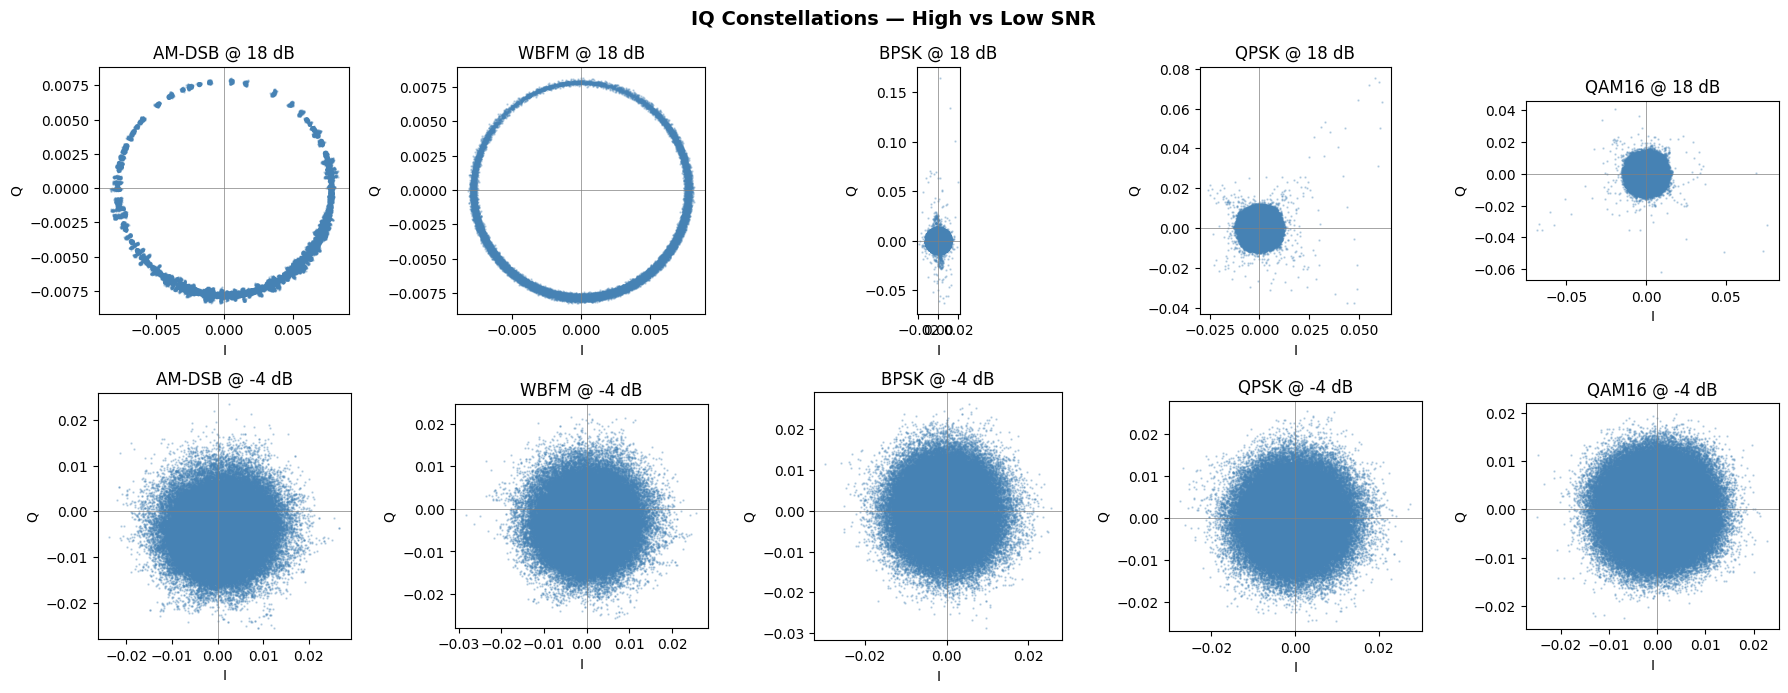

Saved: constellations.png


In [10]:
# ── CELL 4 FIXED: Constellation Plots ─────────────────────────────────────────
HIGH_SNR = 18
LOW_SNR  = -4

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("IQ Constellations — High vs Low SNR", fontsize=14, fontweight="bold")

for col, mod in enumerate(TARGET_MODS):
    for row, snr in enumerate([HIGH_SNR, LOW_SNR]):
        samples = data[(mod, snr)]
        I = samples[:, 0, :].ravel()
        Q = samples[:, 1, :].ravel()

        ax = axes[row, col]
        ax.scatter(I, Q, s=0.5, alpha=0.3, color="steelblue")
        ax.set_title(f"{mod} @ {snr} dB")
        ax.set_xlabel("I"); ax.set_ylabel("Q")
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig("constellations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: constellations.png")

In [11]:
# ── CELL 5: Feature Extraction ────────────────────────────────────────────────

def _kurtosis(x):
    """Excess kurtosis (4th standardized moment - 3)"""
    mu  = np.mean(x)
    std = np.std(x) + 1e-10
    return np.mean(((x - mu) / std) ** 4) - 3.0

def extract_features(sample):
    """
    sample: numpy array of shape (2, 128)
    Returns: 1D feature vector of length 10
    """
    I = sample[0]
    Q = sample[1]

    envelope = np.sqrt(I**2 + Q**2)
    zcr = np.mean(np.diff(np.sign(I)) != 0)

    return np.array([
        np.mean(I**2 + Q**2),       # mean power
        np.var(I),                   # I variance
        np.var(Q),                   # Q variance
        _kurtosis(I),                # I kurtosis
        _kurtosis(Q),                # Q kurtosis
        np.max(envelope),            # max amplitude
        np.std(envelope),            # envelope std  ← key for AM vs FM
        np.mean(envelope),           # envelope mean
        np.mean(np.abs(I - Q)),      # I/Q imbalance
        zcr,                         # zero-crossing rate
    ])

# Extract features for all 110,000 samples
print("Extracting features — this takes ~45 seconds, please wait...")
X_feat = np.array([extract_features(X_raw[i]) for i in range(len(X_raw))])

print(f"Done.")
print(f"Feature matrix shape: {X_feat.shape}")
print(f"First sample features: {X_feat[0].round(6)}")

Extracting features — this takes ~45 seconds, please wait...
Done.
Feature matrix shape: (100000, 10)
First sample features: [7.80000e-05 4.30000e-05 3.50000e-05 2.52759e-01 8.34306e-01 2.33460e-02
 4.14300e-03 7.81200e-03 6.88400e-03 5.43307e-01]


In [13]:
# ── DEBUG: Verify feature matrix ──────────────────────────────────────────────
print(f"X_feat shape : {X_feat.shape}")       # should be (100000, 10)
print(f"y_raw shape  : {y_raw.shape}")        # should be (100000,)
print(f"snrs shape   : {snrs.shape}")         # should be (100000,)

print(f"\nClass counts:")
for mod in TARGET_MODS:
    print(f"  {mod}: {np.sum(y_raw == mod)}")

print(f"\nSNR levels: {sorted(np.unique(snrs))}")

X_feat shape : (100000, 10)
y_raw shape  : (100000,)
snrs shape   : (100000,)

Class counts:
  AM-DSB: 20000
  WBFM: 20000
  BPSK: 20000
  QPSK: 20000
  QAM16: 20000

SNR levels: [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]


In [14]:
# ── CELL 6: Encode Labels + Split ─────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X_feat, y_enc, snrs,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

print(f"\nTrain samples : {X_train.shape[0]}")
print(f"Test samples  : {X_test.shape[0]}")
print(f"\nClass distribution in test set:")
for i, mod in enumerate(le.classes_):
    print(f"  {mod}: {np.sum(y_test == i)}")

Label mapping: {np.str_('AM-DSB'): np.int64(0), np.str_('BPSK'): np.int64(1), np.str_('QAM16'): np.int64(2), np.str_('QPSK'): np.int64(3), np.str_('WBFM'): np.int64(4)}

Train samples : 80000
Test samples  : 20000

Class distribution in test set:
  AM-DSB: 4000
  BPSK: 4000
  QAM16: 4000
  QPSK: 4000
  WBFM: 4000


In [15]:
# ── CELL 7: Train Random Forest ───────────────────────────────────────────────
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training Random Forest...")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
overall_acc = accuracy_score(y_test, y_pred)

print(f"\nOverall test accuracy: {overall_acc:.3f} ({overall_acc*100:.1f}%)")


Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   45.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s



Overall test accuracy: 0.601 (60.1%)


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.9s finished


SNR  -20 dB  →  0.201 (20.1%)
SNR  -18 dB  →  0.233 (23.3%)
SNR  -16 dB  →  0.222 (22.2%)
SNR  -14 dB  →  0.217 (21.7%)
SNR  -12 dB  →  0.233 (23.3%)
SNR  -10 dB  →  0.301 (30.1%)
SNR   -8 dB  →  0.439 (43.9%)
SNR   -6 dB  →  0.511 (51.1%)
SNR   -4 dB  →  0.613 (61.3%)
SNR   -2 dB  →  0.666 (66.6%)
SNR   +0 dB  →  0.740 (74.0%)
SNR   +2 dB  →  0.785 (78.5%)
SNR   +4 dB  →  0.814 (81.4%)
SNR   +6 dB  →  0.844 (84.4%)
SNR   +8 dB  →  0.859 (85.9%)
SNR  +10 dB  →  0.848 (84.8%)
SNR  +12 dB  →  0.884 (88.4%)
SNR  +14 dB  →  0.849 (84.9%)
SNR  +16 dB  →  0.846 (84.6%)
SNR  +18 dB  →  0.865 (86.5%)


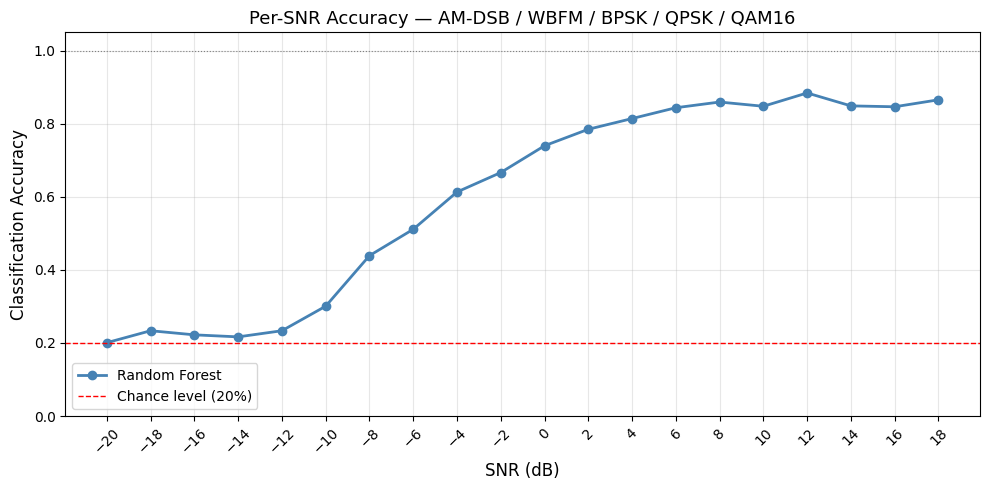

Saved: per_snr_accuracy.png


In [16]:
# ── CELL 8: Per-SNR Accuracy Curve ────────────────────────────────────────────
snr_levels   = sorted(np.unique(snr_test))
snr_accuracy = []

for snr in snr_levels:
    mask = snr_test == snr
    acc  = accuracy_score(y_test[mask], y_pred[mask])
    snr_accuracy.append(acc)
    print(f"SNR {snr:+4d} dB  →  {acc:.3f} ({acc*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snr_levels, snr_accuracy, marker="o", linewidth=2,
        color="steelblue", label="Random Forest")
ax.axhline(1/5, color="red", linestyle="--", linewidth=1,
           label="Chance level (20%)")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("SNR (dB)", fontsize=12)
ax.set_ylabel("Classification Accuracy", fontsize=12)
ax.set_title("Per-SNR Accuracy — AM-DSB / WBFM / BPSK / QPSK / QAM16", fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xticks(snr_levels)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("per_snr_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_snr_accuracy.png")


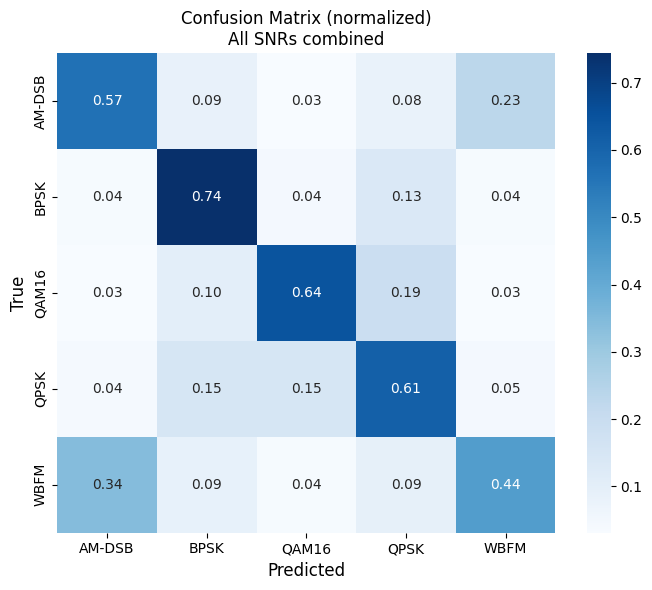

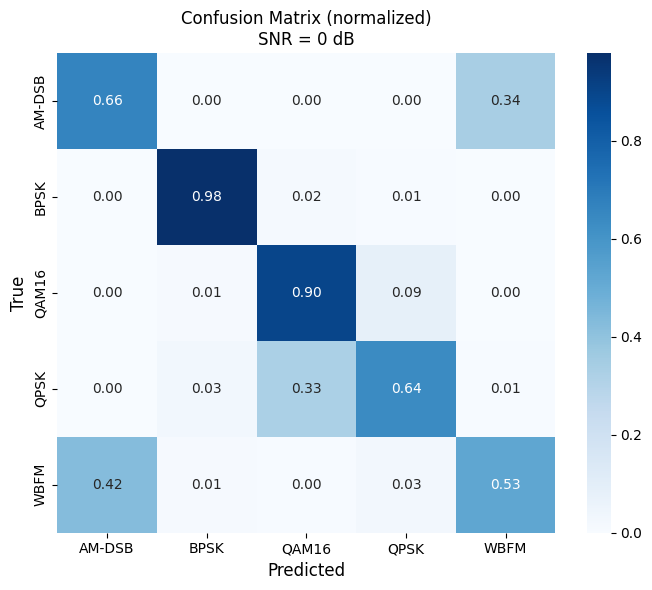

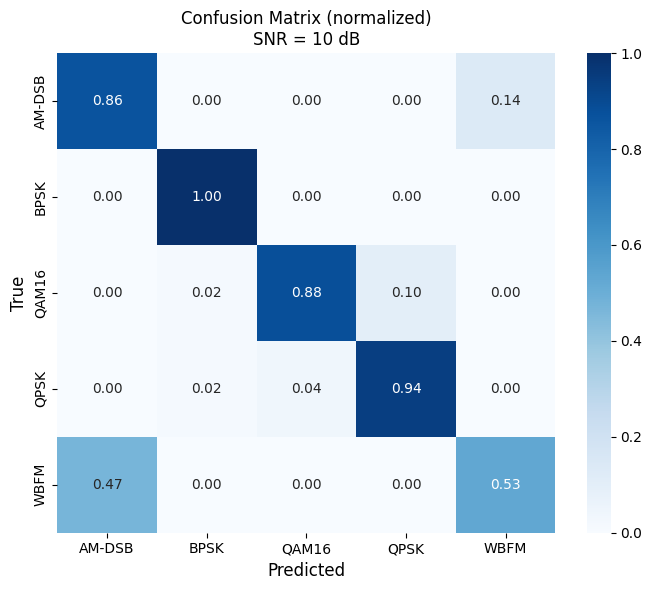

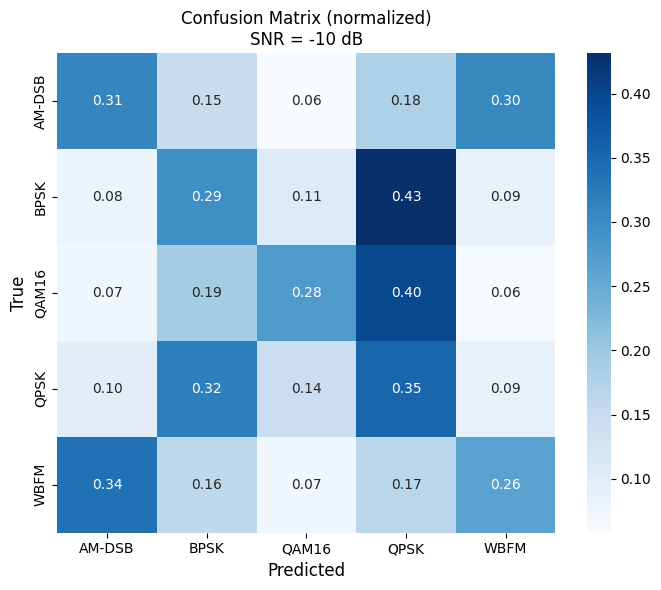

Saved: confusion_matrix_all.png
Saved: confusion_matrix_0dB.png
Saved: confusion_matrix_10dB.png
Saved: confusion_matrix_-10dB.png


In [17]:
# ── CELL 9: Confusion Matrix ──────────────────────────────────────────────────

# Full test set confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix (normalized)\nAll SNRs combined", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-SNR confusion matrix at specific SNR levels ───────────────────────────
for INSPECT_SNR in [0, 10, -10]:
    mask   = snr_test == INSPECT_SNR
    cm_snr = confusion_matrix(y_test[mask], y_pred[mask], normalize="true")

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_snr, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(f"Confusion Matrix (normalized)\nSNR = {INSPECT_SNR} dB", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{INSPECT_SNR}dB.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Saved: confusion_matrix_all.png")
print("Saved: confusion_matrix_0dB.png")
print("Saved: confusion_matrix_10dB.png")
print("Saved: confusion_matrix_-10dB.png")

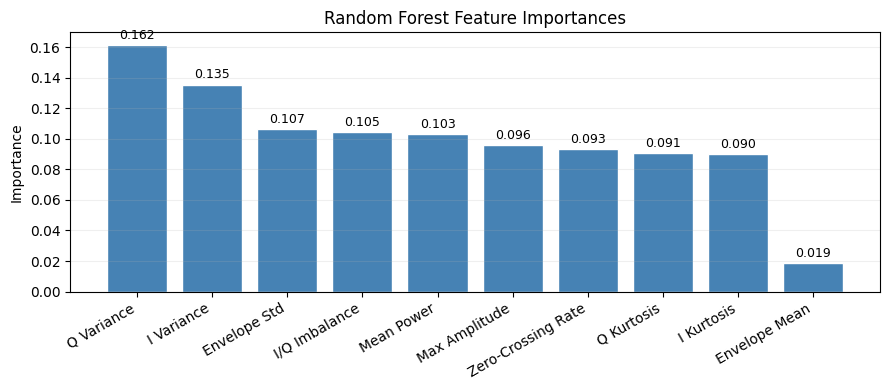


Feature importance ranking:
  1. Q Variance             0.1615
  2. I Variance             0.1355
  3. Envelope Std           0.1066
  4. I/Q Imbalance          0.1045
  5. Mean Power             0.1032
  6. Max Amplitude          0.0957
  7. Zero-Crossing Rate     0.0930
  8. Q Kurtosis             0.0907
  9. I Kurtosis             0.0903
  10. Envelope Mean          0.0190


In [18]:
# ── CELL 10: Feature Importances ──────────────────────────────────────────────
feature_names = [
    "Mean Power",
    "I Variance",
    "Q Variance",
    "I Kurtosis",
    "Q Kurtosis",
    "Max Amplitude",
    "Envelope Std",
    "Envelope Mean",
    "I/Q Imbalance",
    "Zero-Crossing Rate"
]

importances = clf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(importances)),
              importances[sorted_idx],
              color="steelblue", edgecolor="white")
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in sorted_idx],
                   rotation=30, ha="right")
ax.set_ylabel("Importance")
ax.set_title("Random Forest Feature Importances")
ax.grid(True, alpha=0.2, axis="y")

for bar, idx in zip(bars, sorted_idx):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{importances[idx]:.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFeature importance ranking:")
for rank, idx in enumerate(sorted_idx):
    print(f"  {rank+1}. {feature_names[idx]:<22} {importances[idx]:.4f}")